# ETL Pipeline

This notebook follows an ELT (Extract, Load, Transform) approach:
1. Extract: Download historical NDBC buoy data from NOAA.
2. Transform: Initial pass at cleaned and parsed data into an analytics-ready format.
3. Load: Store the curated data in a data lake (S3) with minimal processing.

**Outcome:** An Athena table that provides SQL access to the cleaned dataset for analysis and downstream machine learning workflows.

## Notebook Setup

In [1]:
!pip install ndbc-api

In [2]:
import sys
from pathlib import Path

# Add the src folder (relative to the notebook) to sys.path
src_path = Path("../src").resolve()  # notebooks/etl_pipeline.ipynb
sys.path.append(str(src_path))

from s3_utils import get_s3_client, get_sagemaker_bucket, verify_bucket, upload_df_to_s3
from data_utils import fetch_ndbc_data, clean_ndbc_data
from plot_utils import plot_ndbc_histograms

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


### Create S3 Bucket 

Only need to run this once.

In [3]:
# Setup S3 and bucket
s3_client = get_s3_client()
bucket = get_sagemaker_bucket()

In [4]:
verify_bucket(bucket)

[INFO] Bucket 'sagemaker-us-east-1-318401170150' exists.


True

## Extract

Pull NDBC buoy data using ndbc-api.

In [5]:
BUOY_ID = "46086"
START_DATE = "2023-01-01"
END_DATE = "2026-02-01"

raw_data = fetch_ndbc_data(BUOY_ID, START_DATE, END_DATE)

In [6]:
raw_data.head()

,,WDIR,WSPD,GST,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,DEWP,VIS,TIDE,PTDY
timestamp,station_id,,,,,,,,,,,,,,
2023-01-01 00:00:00,46086,171.0,4.5,5.6,NaN,NaN,NaN,NaN,1014.3,14.8,15.9,13.7,NaN,NaN,NaN
2023-01-01 00:10:00,46086,172.0,4.7,5.9,1.63,11.43,9.33,283.0,1014.2,14.9,15.9,13.8,NaN,NaN,NaN
2023-01-01 00:20:00,46086,164.0,4.9,5.9,NaN,NaN,NaN,NaN,1014.1,14.9,15.9,13.8,NaN,NaN,NaN
2023-01-01 00:30:00,46086,164.0,5.3,6.6,NaN,NaN,NaN,NaN,1014.1,14.9,15.9,13.9,NaN,NaN,NaN
2023-01-01 00:40:00,46086,162.0,5.2,6.6,1.88,13.79,9.55,257.0,1014.0,14.9,15.9,14.0,NaN,NaN,NaN


## Transform

Curate raw data. Standardize and filter out values.

In [7]:
# Clean and add features
data = clean_ndbc_data(raw_data, BUOY_ID)

In [8]:
data.head()

,timestamp,station_id,wind_direction,wind_speed,wind_gust,wave_height,dominant_wave_period,average_wave_period,mean_wave_direction,pressure,air_temperature,water_temperature,dewpoint_temperature,wind_speed_ms,wave_energy
0,2023-01-01 00:10:00,46086,172.0,4.7,5.9,1.63,11.43,9.33,283.0,1014.2,14.9,15.9,13.8,2.417887,30.368367
1,2023-01-01 00:40:00,46086,162.0,5.2,6.6,1.88,13.79,9.55,257.0,1014.0,14.9,15.9,14.0,2.675109,48.739376
2,2023-01-01 01:10:00,46086,154.0,5.8,7.2,1.68,12.12,8.98,271.0,1013.5,14.9,15.9,14.1,2.983775,34.207488
3,2023-01-01 01:40:00,46086,162.0,6.2,7.3,1.80,12.12,8.99,270.0,1013.1,15.0,15.9,14.3,3.189553,39.268800
4,2023-01-01 02:10:00,46086,176.0,7.0,8.2,1.76,11.43,8.94,263.0,1012.7,15.0,15.9,14.3,3.601108,35.405568


In [9]:
len(data)

35591

In [10]:
data.isna().sum()

timestamp               0
station_id              0
wind_direction          0
wind_speed              0
wind_gust               0
wave_height             0
dominant_wave_period    0
average_wave_period     0
mean_wave_direction     0
pressure                0
air_temperature         0
water_temperature       0
dewpoint_temperature    0
wind_speed_ms           0
wave_energy             0
dtype: int64

In [11]:
data.describe()

,timestamp,wind_direction,wind_speed,wind_gust,wave_height,dominant_wave_period,average_wave_period,mean_wave_direction,pressure,air_temperature,water_temperature,dewpoint_temperature,wind_speed_ms,wave_energy
count,35591,35591.000000,35591.000000,35591.000000,35591.000000,35591.000000,35591.000000,35591.000000,35591.000000,35591.000000,35591.000000,35591.000000,35591.000000,35591.000000
mean,2024-01-25 12:24:47.347924992,260.862016,4.337847,5.759717,1.530938,12.618181,7.168739,252.802759,1014.768357,16.230336,17.528437,13.054536,2.231579,34.549665
min,2023-01-01 00:10:00,1.000000,0.000000,0.000000,0.400000,3.000000,3.400000,4.000000,997.100000,9.700000,13.200000,-3.900000,0.000000,1.080000
25%,2023-07-07 11:55:00,254.000000,2.600000,3.900000,1.120000,10.000000,6.010000,212.000000,1012.200000,14.600000,15.700000,11.200000,1.337554,14.915264
50%,2024-01-10 09:40:00,289.000000,4.000000,5.400000,1.360000,12.900000,6.870000,273.000000,1014.500000,16.000000,17.300000,13.100000,2.057776,23.140625
75%,2024-07-14 21:55:00,304.000000,5.700000,7.200000,1.750000,14.810000,8.000000,287.000000,1017.100000,17.900000,19.500000,15.400000,2.932331,38.424768
max,2026-01-31 23:50:00,360.000000,15.700000,20.500000,6.350000,23.530000,15.500000,357.000000,1028.300000,22.500000,23.000000,21.200000,8.076771,667.633920
std,NaN,80.399611,2.333001,2.699847,0.629056,3.237689,1.602673,44.514254,3.703043,2.189194,2.222748,3.102449,1.200198,38.721974


In [12]:
data.head()

,timestamp,station_id,wind_direction,wind_speed,wind_gust,wave_height,dominant_wave_period,average_wave_period,mean_wave_direction,pressure,air_temperature,water_temperature,dewpoint_temperature,wind_speed_ms,wave_energy
0,2023-01-01 00:10:00,46086,172.0,4.7,5.9,1.63,11.43,9.33,283.0,1014.2,14.9,15.9,13.8,2.417887,30.368367
1,2023-01-01 00:40:00,46086,162.0,5.2,6.6,1.88,13.79,9.55,257.0,1014.0,14.9,15.9,14.0,2.675109,48.739376
2,2023-01-01 01:10:00,46086,154.0,5.8,7.2,1.68,12.12,8.98,271.0,1013.5,14.9,15.9,14.1,2.983775,34.207488
3,2023-01-01 01:40:00,46086,162.0,6.2,7.3,1.80,12.12,8.99,270.0,1013.1,15.0,15.9,14.3,3.189553,39.268800
4,2023-01-01 02:10:00,46086,176.0,7.0,8.2,1.76,11.43,8.94,263.0,1012.7,15.0,15.9,14.3,3.601108,35.405568


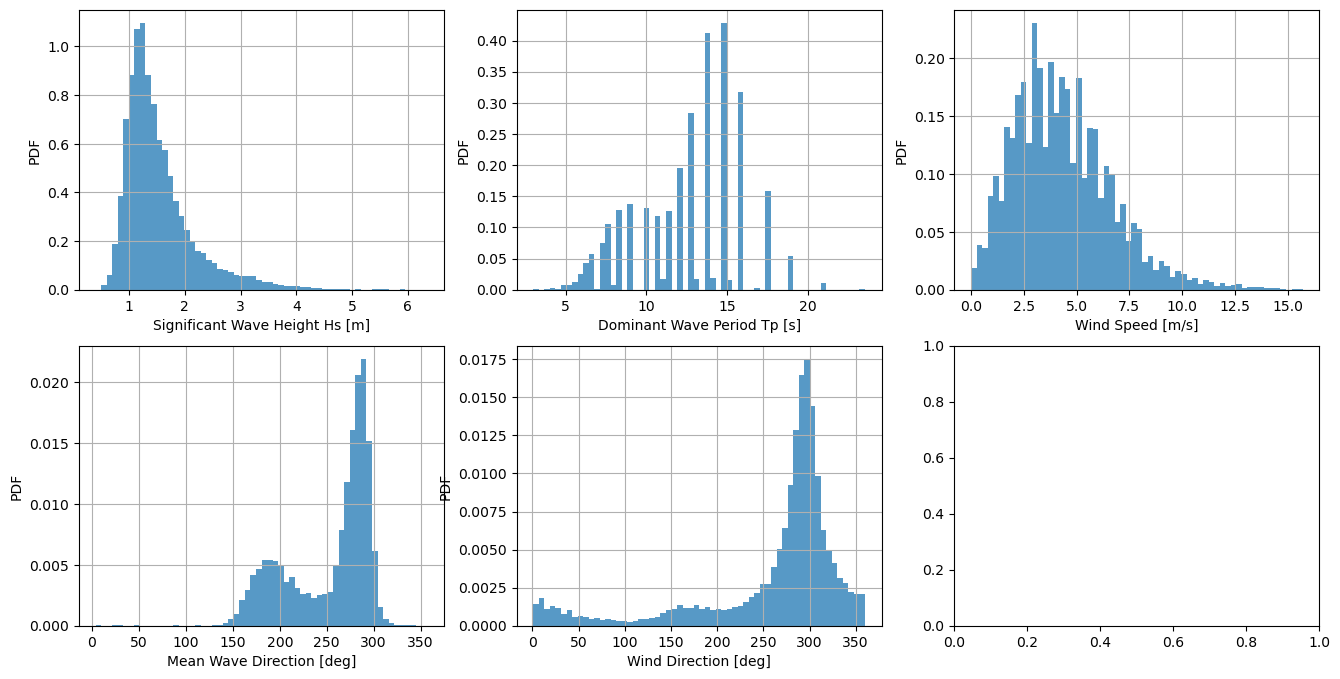

In [13]:
plot_ndbc_histograms(data)

## Load 

Serialize and upload directly to S3.

In [14]:
# Upload to S3
CURATED_PREFIX = "curated/ndbc"
s3_path = upload_df_to_s3(data, bucket, CURATED_PREFIX, BUOY_ID, s3_client=s3_client)

[INFO] Uploaded to s3://sagemaker-us-east-1-318401170150/curated/ndbc/buoy=46086/stdmet.parquet


In [15]:
%store CURATED_PREFIX
%store bucket

Stored 'CURATED_PREFIX' (str)
Stored 'bucket' (str)


In [16]:
from IPython.core.display import display, HTML
import boto3

# Get region from your boto3 client/session
region = boto3.Session().region_name

# Build the S3 console URL for your bucket
s3_console_url = (
    f"https://s3.console.aws.amazon.com/s3/buckets/{bucket}/"
    f"?region={region}&tab=overview"
)

display(
    HTML(
        f'<b>Review <a target="_blank" href="{s3_console_url}">S3 Bucket</a></b>'
    )
)


/tmp/ipykernel_1975/914977500.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


## Cleanup
### Store Variables

In [17]:
%store s3_path

Stored 's3_path' (str)


## Release Resources

In [18]:
%%html

<p><b>Shutting down your kernel for this notebook to release resources.</b></p>
<button class="sm-command-button" data-commandlinker-command="kernelmenu:shutdown" style="display:none;">Shutdown Kernel</button>
        
<script>
try {
    els = document.getElementsByClassName("sm-command-button");
    els[0].click();
}
catch(err) {
    // NoOp
}    
</script>

In [1]:
%%javascript

try {
    Jupyter.notebook.save_checkpoint();
    Jupyter.notebook.session.delete();
}
catch(err) {
    // NoOp
}

<IPython.core.display.Javascript object>